#### 1. Data Exploration:
- a. Load the dataset and perform exploratory data analysis (EDA).
- b. Examine the features, their types, and summary statistics.
- c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.


In [65]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import pickle

In [2]:
##loading data 
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
print(f"\nShape: {df.shape}")
print("=" * 70)
print(f"\nColumn types:\n {df.dtypes}")
print("=" * 70)
print(f"\nSummary statistics:\n{df.describe().T}")
print("=" * 70)
print(f"\nClass balance (Outcome):\n{df['Outcome'].value_counts()}")
print("=" * 70)
# print(f"  -> {df['Outcome'].mean()*100:.1f}% positive (diabetic) cases")


Shape: (768, 9)

Column types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Summary statistics:
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.2

In [12]:
##handling the missing data
## the below 5 rows contains zero which we consider as null value so  changing the zero to null
replacing_zeros_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print('\nZeros (trated as null values):')
for c in replacing_zeros_cols:
    n_zero=(df[c]==0).sum()
    print(f"{c:15s}:{n_zero:4d} zeros ({n_zero/len(df)*100:.1f}%)")




Zeros (trated as null values):
Glucose        :   5 zeros (0.7%)
BloodPressure  :  35 zeros (4.6%)
SkinThickness  : 227 zeros (29.6%)
Insulin        : 374 zeros (48.7%)
BMI            :  11 zeros (1.4%)


#### visuvalization

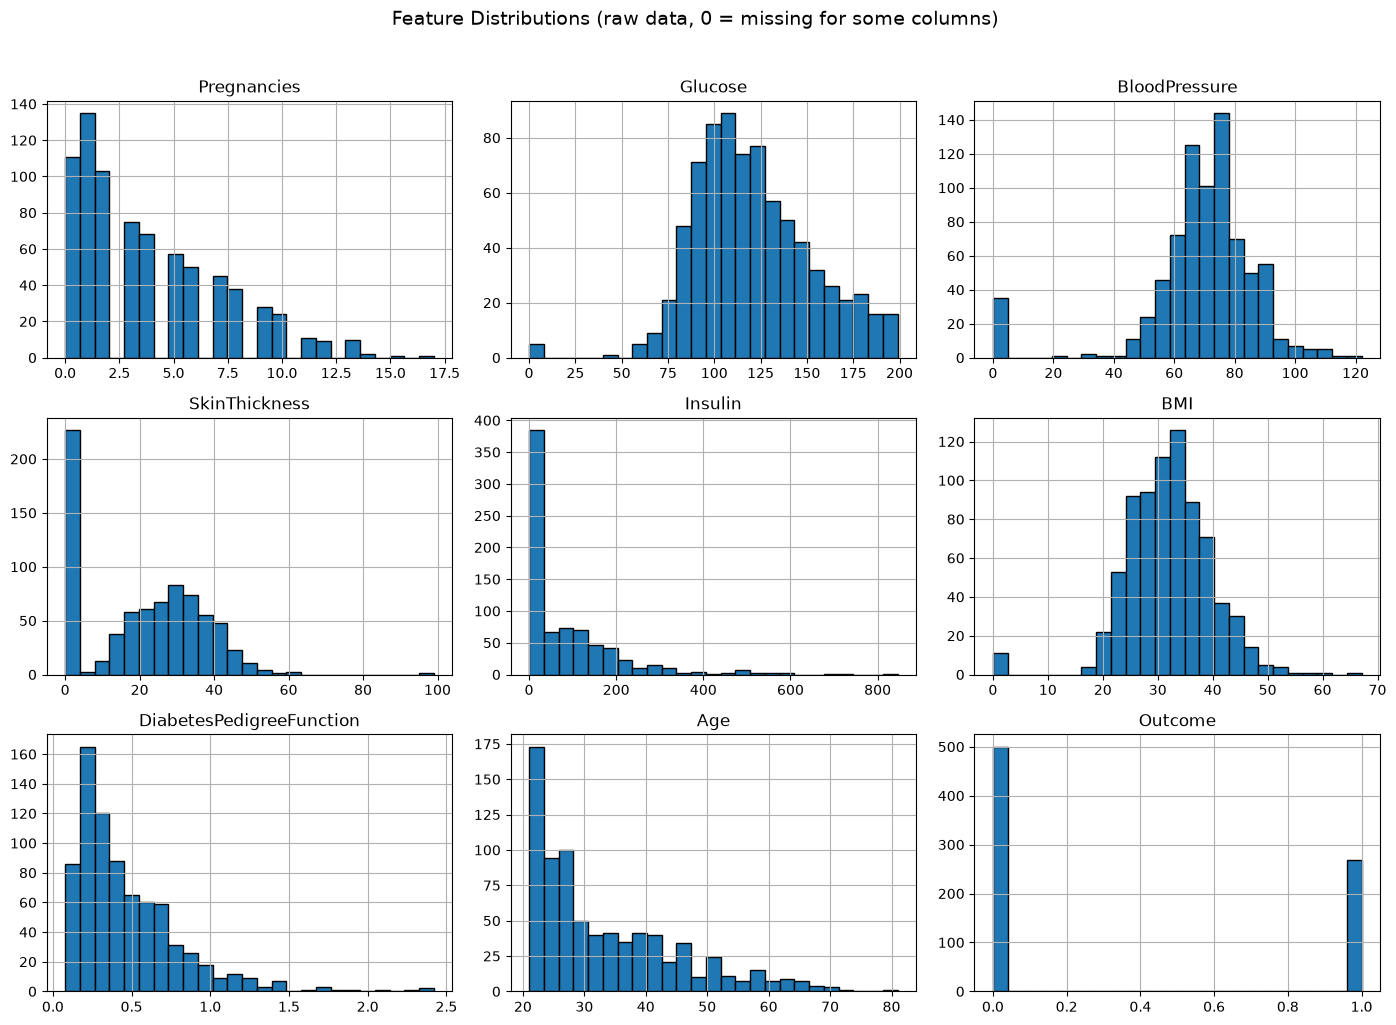

In [18]:
## histogram of all features 
df.hist(bins=25, figsize=(14, 10), edgecolor="black")
plt.suptitle("Feature Distributions (raw data, 0 = missing for some columns)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("01_histograms.png", bbox_inches="tight")
plt.show()


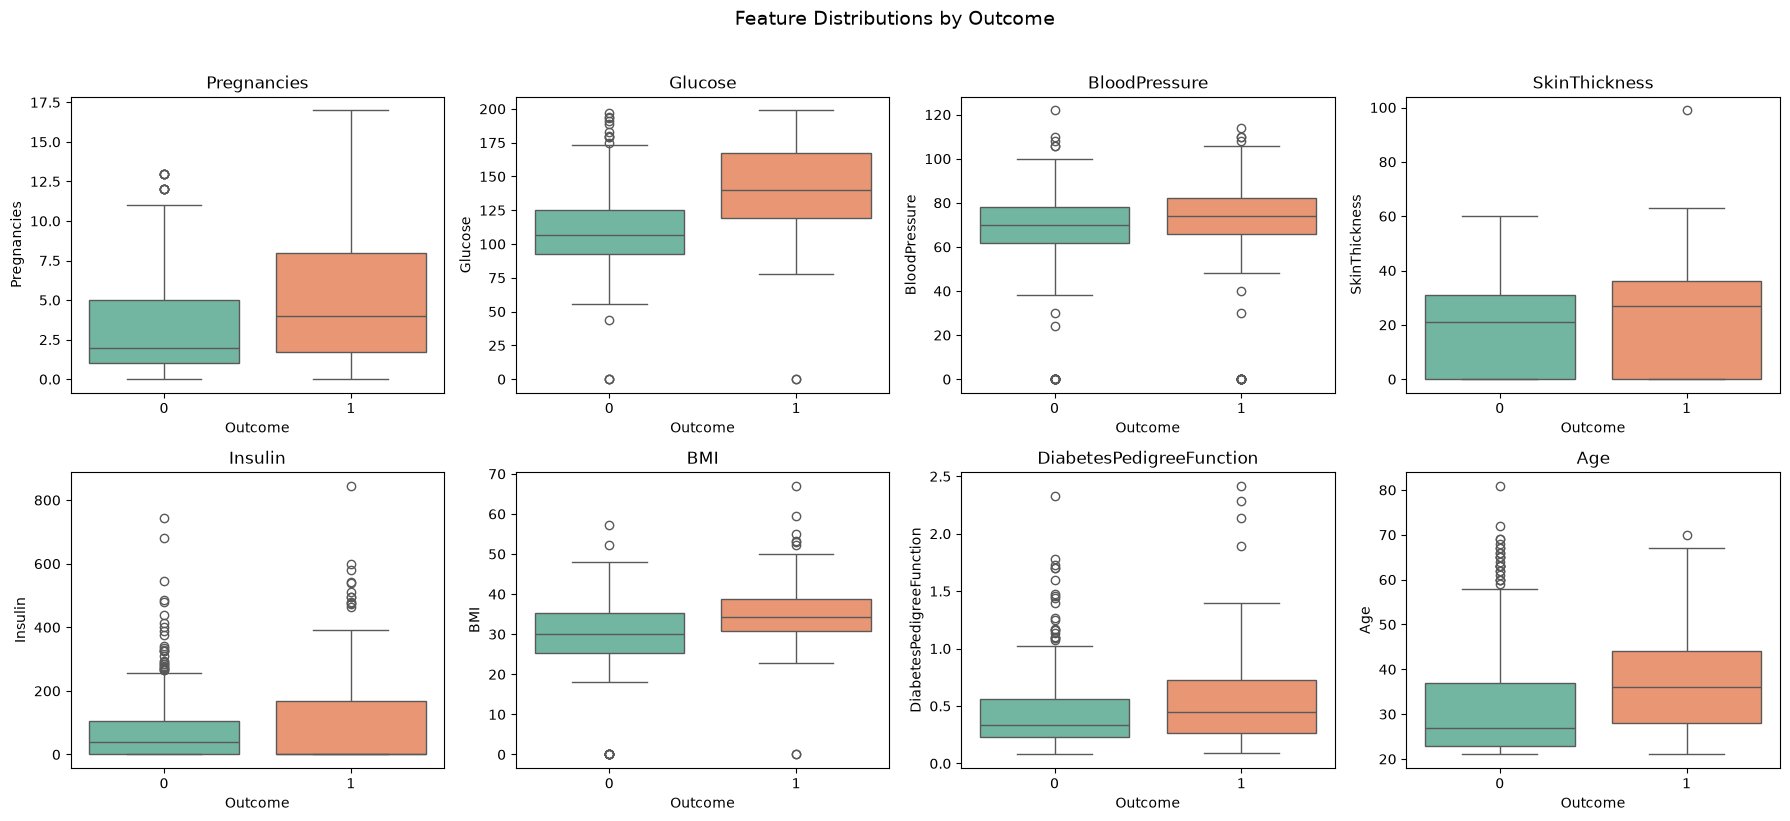

In [23]:
# Box plots by outcome for each feature
features = [c for c in df.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Outcome", y=feat, ax=ax, hue='Outcome',palette="Set2",legend=False)
    ax.set_title(feat)
plt.suptitle("Feature Distributions by Outcome", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("02_boxplots_by_outcome.png", bbox_inches="tight")
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'save'

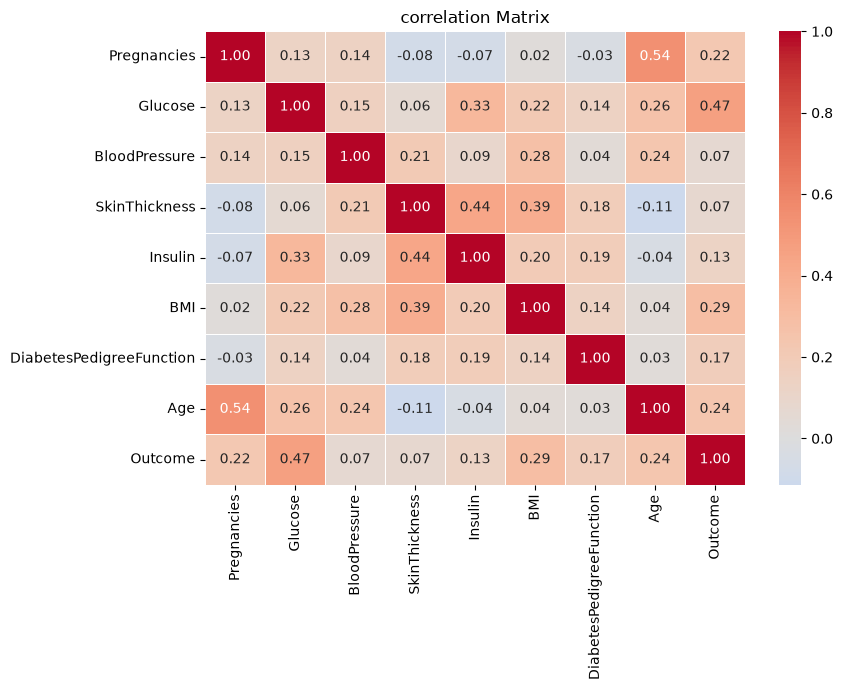

In [26]:
## corealtion heatmap
plt.figure(figsize=(9,7))
corr=df.corr()
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,linewidths=0.5)
plt.title("correlation Matrix")
plt.tight_layout()
plt.save("03_correlation_heatmap.png",bbox_inches="tight")
plt.show()

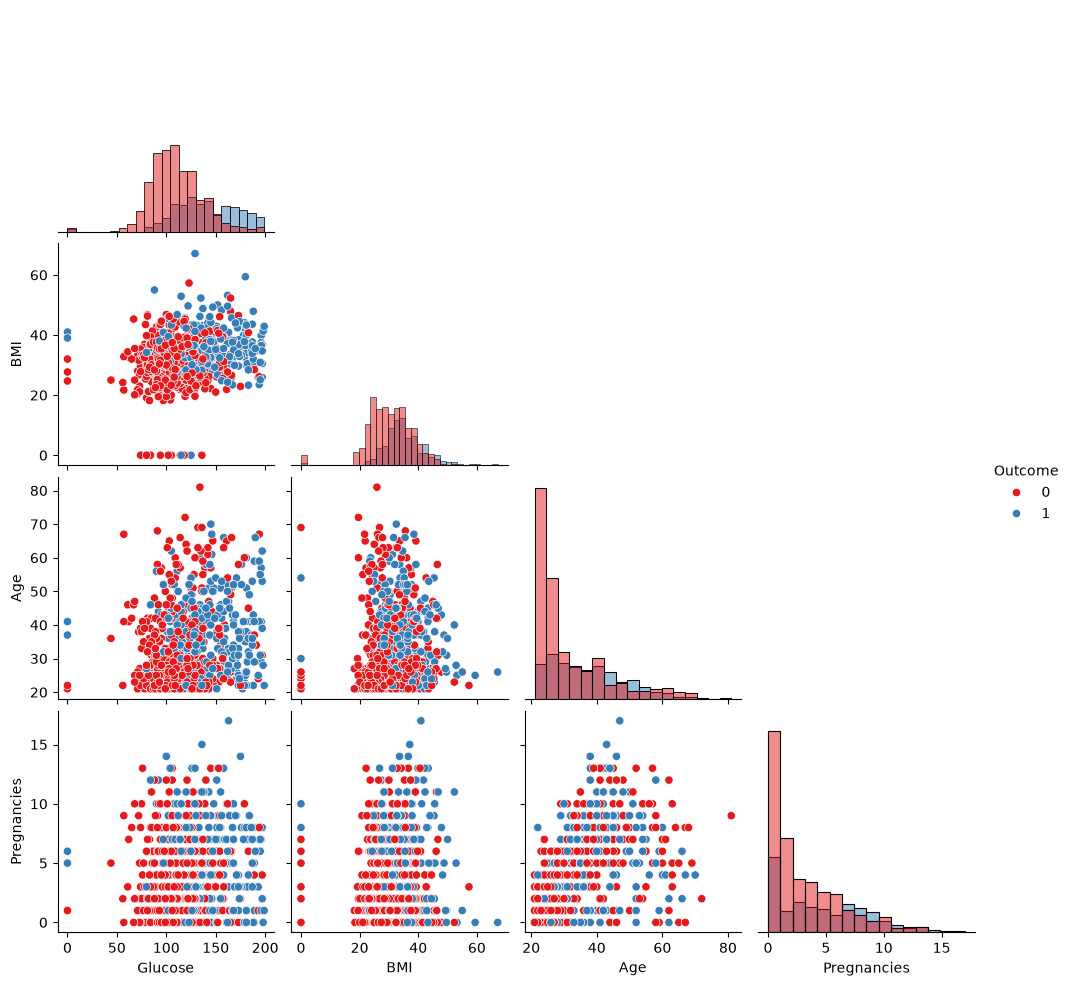

In [27]:
# Pairplot of the most correlated features with Outcome
top_feats = corr["Outcome"].abs().sort_values(ascending=False).index[1:5].tolist()
sns.pairplot(df, vars=top_feats, hue="Outcome", palette="Set1", diag_kind="hist", corner=True)
plt.savefig("04_pairplot_top_features.png", bbox_inches="tight")
plt.show()

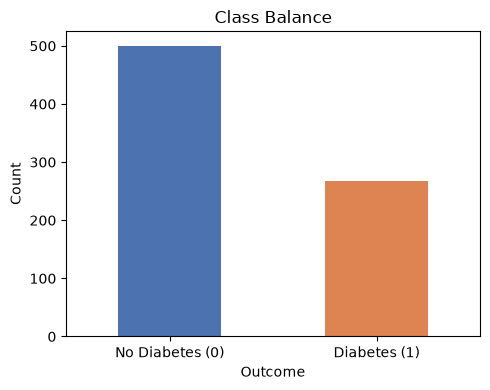

In [29]:
# Class balance bar chart
plt.figure(figsize=(5, 4))
df["Outcome"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["No Diabetes (0)", "Diabetes (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Class Balance")
plt.tight_layout()
plt.savefig("05_class_balance.png", bbox_inches="tight")
plt.show()

In [30]:
print("\nTop correlations with Outcome:")
print(corr["Outcome"].abs().sort_values(ascending=False)[1:])


Top correlations with Outcome:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


#### EDA Obseeravtion :
- **glucose** has highest/stogest correlation with the Outcomes 
- **insulin** and skinThinkness have very high missing valiues 
- **boxplot** shows diabetics patients tends to have higher **Glucose,BMI,Age and pregnancies** than non-diabetics patients

## DATA PREPROCESSING 
- a. Handle missing values (e.g., imputation).
- b. Encode categorical variables.


In [45]:
## coping data into df_clean and replacings zeros with misising values 
df_clean=df.copy()

for c in replacing_zeros_cols:
    df_clean[c] = df_clean[c].replace(0, np.nan)
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

##printing missing values 
print("\nMissing values after converting zeros to NaN:")
print(df_clean.isnull().sum())



Missing values after converting zeros to NaN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [50]:
## declaring input and output variable 
X=df_clean.drop(columns=['Outcome'])
y=df_clean["Outcome"]

In [51]:
## No categrical data in this data 
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical columns: {categorical_cols if categorical_cols else 'None'}")
print(f"Numeric columns: {numeric_cols}")


Categorical columns: None
Numeric columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [52]:
## spliting traing and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 614, Test size: 154


In [53]:
#appling standarscalr on the features 
scalar=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.fit_transform(X_test)

## 3. Model Building:
- a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
- b. Train the model using the training data.


In [54]:
model=LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train_scaled,y_train)
print("\nModel trained successfully.")


Model trained successfully.


In [55]:
# Cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
print(f"5-fold CV ROC-AUC on training data: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-fold CV ROC-AUC on training data: 0.8428 (+/- 0.0190)


## 4. Model Evaluation:
- a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.


In [57]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("=" * 70)
print(f"\nClassification report:\n{classification_report(y_test, y_pred)}")


Accuracy : 0.7013
Precision: 0.5909
Recall   : 0.4815
F1-score : 0.5306
ROC-AUC  : 0.8126

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



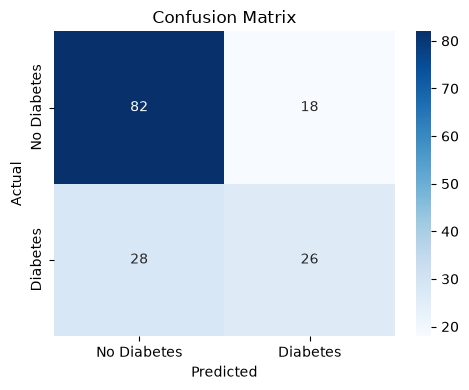

In [59]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("06_confusion_matrix.png", bbox_inches="tight")
plt.show()

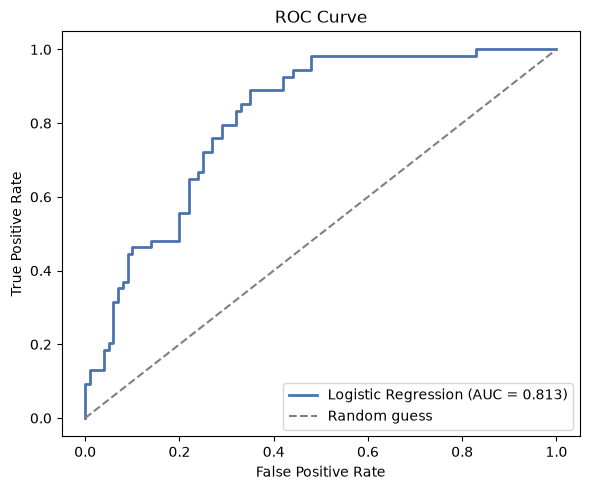

In [60]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="#4C72B0", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("07_roc_curve.png", bbox_inches="tight")
plt.show()

## 5. Interpretation:
- a. Interpret the coefficients of the logistic regression model.
- b. Discuss the significance of features in predicting the target variable (survival probability in this case).


In [61]:
coefs = model.coef_[0]
odds_ratios = np.exp(coefs)
coef_df = pd.DataFrame({
    "Feature": numeric_cols,
    "Coefficient": coefs,
    "Odds Ratio": odds_ratios
}).sort_values("Coefficient", key=abs, ascending=False)

In [62]:
print("\nLogistic Regression Coefficients (standardized features):")
print(coef_df.to_string(index=False))


Logistic Regression Coefficients (standardized features):
                 Feature  Coefficient  Odds Ratio
                 Glucose     1.182511    3.262558
                     BMI     0.688735    1.991194
             Pregnancies     0.377502    1.458637
DiabetesPedigreeFunction     0.233386    1.262869
                     Age     0.147798    1.159279
                 Insulin    -0.066157    0.935983
           BloodPressure    -0.044066    0.956891
           SkinThickness     0.028225    1.028627


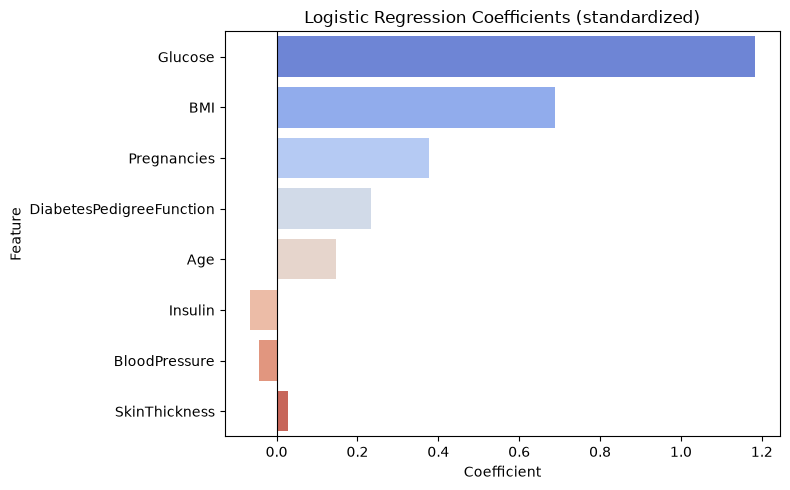

In [64]:
plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="coolwarm")
plt.title("Logistic Regression Coefficients (standardized)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("08_coefficients.png", bbox_inches="tight")
plt.show()


- **Glucose,BMI,Pregnancies,anand Diabetes Pedigree Functions** turned out to be the strogest features pushing risk up -which matches what we already know:high blood sugar and higher body weight are major risk factores for diabetes
- **odd ration =exp(coffecient )**,if it is **above 1** , the feature makes **diabetes more likely** ;if it's  **below 1**, it makes **diabetes less likely**.
- we scaled the features first , so each cofficient tells us how much feature's typical up-or-down swing change a person's diabetes risk ,while keeping all other features the same.

### save the model

In [67]:
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)
 
with open("scaler.pkl", "wb") as f:
    pickle.dump(scalar, f)
 
# Save the median values used for imputation — the Streamlit app needs these
# to apply the *exact same* imputation to new user input at prediction time.
medians = X[numeric_cols].median()
medians.to_csv("feature_medians.csv")
 
print("\nSaved: diabetes_model.pkl, scaler.pkl, feature_medians.csv, plots/*.png")
print("\nDone.")


Saved: diabetes_model.pkl, scaler.pkl, feature_medians.csv, plots/*.png

Done.
